<a href="https://colab.research.google.com/github/faishal-ai/machine-learning_2025/blob/main/UTS_ML_2341720218_Faishal_Harist_Rahmawan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **UTS Faishal Harist Rahmawan**

# ===============================================
# UTS Pembelajaran Mesin - Heart Disease Dataset
# Nama  : Faishal Harist Rahmawan
# Absen : 10
# NIM   : 2341720218
# ===============================================

In [ ]:
!pip install annoy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 11.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp312-cp312-linux_x86_64.whl size=551519 sha256=89f4fdc19341138754d1175a5cc594417aa6a1b3ffbf91d9c03faec028421cd8
  Stored in directory: /root/.cache/pip/wheels/db/b9/53/a3b2d1fe1743abadddec6aa541294b24fdbc39d7800bc57311
Successfully built annoy


In [ ]:
# 1 Import Library
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from annoy import AnnoyIndex
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [ ]:
# 2️ Google Drive & Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

 Statistik Awal:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610 

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



 Missing Values per Kolom:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

 Data sudah dinormalisasi. Bentuk data: (1025, 15)

 Evaluasi Clustering:
KMeans → Silhouette: 0.1468, DBI: 2.2231
DBSCAN → Silhouette: -0.1957, DBI: 1.3457


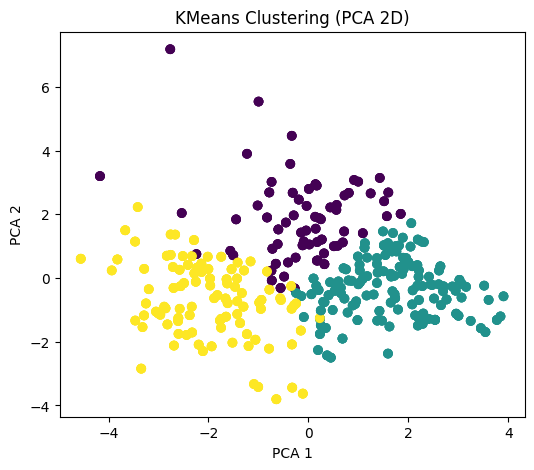

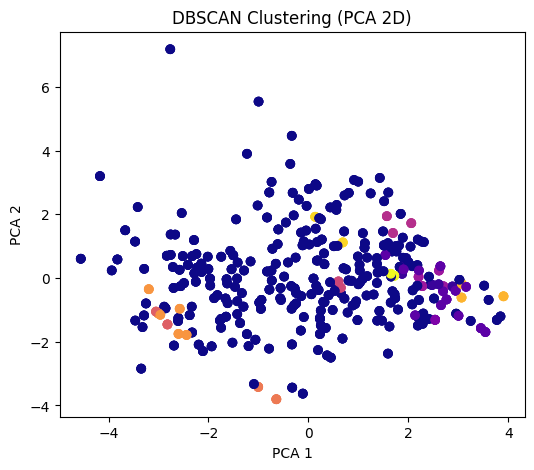


 Hasil Pencarian Tetangga Terdekat:

Query Index: 420 (Cluster KMeans: 0)
 - Neighbor: 96, Distance: 0.0000, Cluster: 0
 - Neighbor: 420, Distance: 0.0000, Cluster: 0
 - Neighbor: 490, Distance: 0.0000, Cluster: 0
 - Neighbor: 533, Distance: 2.1738, Cluster: 1
 - Neighbor: 565, Distance: 2.1738, Cluster: 1

Query Index: 31 (Cluster KMeans: 1)
 - Neighbor: 18, Distance: 0.0000, Cluster: 1
 - Neighbor: 31, Distance: 0.0000, Cluster: 1
 - Neighbor: 907, Distance: 0.0000, Cluster: 1
 - Neighbor: 234, Distance: 1.5673, Cluster: 1
 - Neighbor: 761, Distance: 1.5673, Cluster: 1

Query Index: 703 (Cluster KMeans: 1)
 - Neighbor: 353, Distance: 0.0000, Cluster: 1
 - Neighbor: 703, Distance: 0.0000, Cluster: 1
 - Neighbor: 887, Distance: 0.0000, Cluster: 1
 - Neighbor: 161, Distance: 2.8139, Cluster: 1
 - Neighbor: 745, Distance: 2.8139, Cluster: 1


In [ ]:
# ===============================================
# UTS Pembelajaran Mesin - Heart Disease Dataset
# Nama  : Faishal Harist Rahmawan
# Absen : 10
# NIM   : 2341720218
# ===============================================

# dataset
df = pd.read_csv('/content/drive/MyDrive/Mesin-L/heart.csv')

print(" Info Dataset:")
print(df.info())
print("\n Statistik Awal:")
print(df.describe())
print("\n 5 Data Teratas:")
display(df.head())

# 3️ data Preprocessing

print("\n Missing Values per Kolom:")
print(df.isnull().sum())

# missing values
df.fillna(df.mean(), inplace=True)

# fitur baru: CholAge = cholesterol × age
df['CholAge'] = df['chol'] * df['age']

# fitur numerik
num_df = df.select_dtypes(include=['float64', 'int64'])

# normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(num_df)

print("\n Data sudah dinormalisasi. Bentuk data:", X_scaled.shape)


# 4️ clustering: KMeans dan DBSCAN
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, labels_kmeans)
dbi_kmeans = davies_bouldin_score(X_scaled, labels_kmeans)
sil_dbscan = silhouette_score(X_scaled, labels_dbscan)
dbi_dbscan = davies_bouldin_score(X_scaled, labels_dbscan)

print("\n Evaluasi Clustering:")
print(f"KMeans → Silhouette: {sil_kmeans:.4f}, DBI: {dbi_kmeans:.4f}")
print(f"DBSCAN → Silhouette: {sil_dbscan:.4f}, DBI: {dbi_dbscan:.4f}")


# 5️ visualisasi Clustering (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans, cmap='viridis')
plt.title("KMeans Clustering (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_dbscan, cmap='plasma')
plt.title("DBSCAN Clustering (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


# 6️ approximate Nearest Neighbor (Annoy)
dim = X_scaled.shape[1]
ann = AnnoyIndex(dim, 'euclidean')

for i in range(len(X_scaled)):
    ann.add_item(i, X_scaled[i])

ann.build(10)

query_points = random.sample(range(len(X_scaled)), 3)

print("\n Hasil Pencarian Tetangga Terdekat:")
for q in query_points:
    neighbors, distances = ann.get_nns_by_item(q, 5, include_distances=True)
    print(f"\nQuery Index: {q} (Cluster KMeans: {labels_kmeans[q]})")
    for n, d in zip(neighbors, distances):
        print(f" - Neighbor: {n}, Distance: {d:.4f}, Cluster: {labels_kmeans[n]}")


### **Kesimpulan**

**a. Perbedaan hasil K-Means dan DBSCAN**
Berdasarkan hasil pengujian, metode **K-Means** memberikan hasil pengelompokan yang lebih baik dibandingkan **DBSCAN**. Nilai *Silhouette Score* K-Means sebesar **0.1468** menunjukkan bahwa data masih memiliki struktur cluster yang cukup jelas, sedangkan DBSCAN menghasilkan nilai *Silhouette* negatif (**–0.1957**) yang menandakan banyak data tidak terkelompok dengan baik.
**Dari hasil visualisasi PCA, K-Means membentuk tiga cluster yang cukup terpisah, sedangkan DBSCAN cenderung mengelompokkan sebagian besar data ke dalam satu cluster besar dan beberapa titik sebagai noise.
Dengan demikian, K-Means lebih sesuai digunakan untuk dataset Heart Disease ini karena mampu membentuk cluster yang lebih stabil dan mudah dianalisis.**

---

**b. Nilai metrik terbaik (Silhouette dan DBI)**
Nilai evaluasi metrik menunjukkan hasil sebagai berikut:

* **K-Means:** Silhouette = **0.1468**, DBI = **2.2231**
* **DBSCAN:** Silhouette = **–0.1957**, DBI = **1.3457**

**Walaupun DBSCAN memiliki nilai DBI yang lebih kecil, nilai *Silhouette*-nya yang negatif menunjukkan performa clustering yang kurang baik.**
Oleh karena itu, metode K-Means memiliki nilai metrik terbaik secara keseluruhan, karena menghasilkan pemisahan cluster yang lebih jelas dan konsisten.

---

**c. Hasil query Annoy**
Dari hasil implementasi Approximate Nearest Neighbor (Annoy), titik-titik query yang diuji (index 420, 31, dan 703) memiliki sebagian besar tetangga terdekat yang berada pada cluster yang sama.
Hal ini menunjukkan bahwa hasil clustering K-Means sudah cukup representatif, di mana data dalam cluster yang sama memang memiliki jarak fitur yang berdekatan.
Dengan kata lain, **Annoy berhasil mengonfirmasi bahwa hasil K-Means memiliki konsistensi spasial yang baik antar data dalam satu cluster.**


